# Coherent physical-noise CSB learning and PEC


The workflow is
$
\text{coherent physical-noise CSB}
\rightarrow
\text{logical spectra}
\rightarrow
\text{effective Pauli reconstruction}
\rightarrow
\text{held-out }R_Y\text{ validation}
\rightarrow
\text{random-circuit PEC}.
$

In [1]:
from importlib import reload
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

import logical_csb as lc
reload(lc)

# ============================================================
# Unified paper figure style
# ============================================================

SINGLE_COLUMN_WIDTH = 3.45
DOUBLE_COLUMN_WIDTH = 8.60

PAPER_RC = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "stixsans",
    "font.size": 7.2,
    "axes.labelsize": 8.2,
    "axes.titlesize": 8.2,
    "xtick.labelsize": 7.2,
    "ytick.labelsize": 7.2,
    "legend.fontsize": 6.4,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.1,
    "lines.markersize": 4.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
}

def format_axis(ax):
    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=True,
        right=True,
        width=0.8,
        length=3.0,
    )
    ax.tick_params(axis="both", which="minor", length=1.8)

def panel_label(ax, text):
    ax.text(
        -0.14,
        1.045,
        text,
        transform=ax.transAxes,
        fontsize=9.5,
        fontweight="bold",
        ha="left",
        va="top",
        clip_on=False,
    )


## 1. Simulation settings

In [2]:
BASE_SEED = 1234
N_JOBS = -1

MIN_EC_ROUNDS = 2
MAX_EC_ROUNDS = 4
DECODER_CACHE = Path("steane_flag_decoder_stabilizer_max4.pkl")

# Coherent physical Z-rotation error model
COHERENT_ANGLE = 0.010
TWO_QUBIT_ANGLE_FACTOR = 2.0
IDLE_ANGLE_FACTOR = 1.0

# Ideal logical state preparation, noisy measurement-basis rotations,
# and one FTEC cycle after every logical primitive.
CIRCUIT_OPTIONS = {
    "prep_gates_noisy": True,
    "prep_qec_after_gate": True,
    "measurement_basis_gates_noisy": True,
    "qec_after_each_logical_gate": True,
    "fallback_on_unverified": True,
}

# CSB
CSB_STEPS = list(range(13))
CSB_REP = 17
CSB_SHOTS = 1000
CSB_CHUNK_SHOTS = 100

# Random-circuit PEC validation
RB_DEPTHS = [4, 8, 12, 16]
RB_SEQUENCES_PER_DEPTH = 12
RB_NOISY_SHOTS_PER_SEQUENCE = 10000
RB_PEC_SHOTS_PER_SEQUENCE = 10000
RB_CHUNK_SHOTS = 100

# Independent complete learning + validation workflows.
# Set to 1 for a single expensive production run.
N_COMPLETE_REPEATS = 10
SEED_STRIDE = 10_000_019

noise = lc.make_homogeneous_coherent_noise(
    strength=COHERENT_ANGLE,
    two_qubit_factor=TWO_QUBIT_ANGLE_FACTOR,
    idle_factor=IDLE_ANGLE_FACTOR,
)

decoder = lc.get_or_build_decoder(
    cache_file=DECODER_CACHE,
    min_rounds=MIN_EC_ROUNDS,
    max_rounds=MAX_EC_ROUNDS,
    verbose=False,
)

## 2. Coherent random-circuit PEC driver

In [3]:
def _chunk_sizes(total, chunk):
    total = int(total)
    chunk = max(1, int(chunk))
    sizes = []
    while total > 0:
        n = min(total, chunk)
        sizes.append(n)
        total -= n
    return sizes


def _coherent_sequence_sample(
    decoder,
    noise,
    options,
    sequence,
    shots,
    seed,
    inverse_q=None,
):
    rng = np.random.default_rng(int(seed))
    values = np.empty(int(shots), dtype=float)

    for shot in range(int(shots)):
        sim = lc.CoherentSteaneFTSimulator(
            decoder,
            noise,
            options,
            seed=int(rng.integers(2**32 - 1)),
        )
        sim.prepare_initial("0")

        weight = 1.0

        for gate in sequence:
            correction = "I"
            if inverse_q is not None:
                correction, q_weight = lc.sample_inverse_pauli(
                    rng,
                    inverse_q,
                )
                weight *= q_weight

            sim.apply_logical_gate(
                gate,
                noisy=True,
                apply_qec=options["qec_after_each_logical_gate"],
                post_ec_logical_pauli=correction,
            )

        outcome = sim.measure_logical_pauli("Z")
        values[shot] = weight * outcome

    mean = float(np.mean(values))
    stderr = (
        float(np.std(values, ddof=1) / math.sqrt(shots))
        if int(shots) > 1
        else 0.0
    )

    return mean, stderr


def run_coherent_random_circuit_pec(
    decoder,
    noise,
    options,
    pauli_df,
    depths,
    sequences_per_depth,
    noisy_shots,
    pec_shots,
    seed,
    n_jobs,
    chunk_shots,
    cache_file,
    min_rounds,
    max_rounds,
):
    row = pauli_df.iloc[0]
    probs = np.array(
        [row["p_I"], row["p_X"], row["p_Y"], row["p_Z"]],
        dtype=float,
    )
    inverse_q = lc.inverse_pauli_quasiprobabilities_from_probs(probs)

    rng = np.random.default_rng(int(seed))
    records = []

    for depth in map(int, depths):
        for sequence_id in range(int(sequences_per_depth)):
            forward = [
                lc.PRIMITIVE_GATES[
                    int(rng.integers(len(lc.PRIMITIVE_GATES)))
                ]
                for _ in range(depth)
            ]
            inverse = lc.inverse_word_for_sequence(forward)
            records.append(
                {
                    "depth": depth,
                    "sequence_id": sequence_id,
                    "sequence": forward + inverse,
                }
            )

    cache_path = str(cache_file)
    if not Path(cache_path).exists() and hasattr(decoder, "save"):
        decoder.save(cache_path)

    tasks = []
    for record_id, record in enumerate(records):
        for mode, total_shots in (
            ("noisy", noisy_shots),
            ("pec", pec_shots),
        ):
            for n in _chunk_sizes(total_shots, chunk_shots):
                tasks.append(
                    {
                        "record_id": record_id,
                        "mode": mode,
                        "shots": int(n),
                        "seed": int(rng.integers(2**32 - 1)),
                    }
                )

    def run_task(task):
        dec = lc.get_worker_decoder(
            cache_path,
            min_rounds,
            max_rounds,
        )
        record = records[task["record_id"]]
        inv = inverse_q if task["mode"] == "pec" else None

        mean, stderr = _coherent_sequence_sample(
            dec,
            noise,
            options,
            record["sequence"],
            task["shots"],
            task["seed"],
            inverse_q=inv,
        )

        n = int(task["shots"])
        sample_var = stderr**2 * n if n > 1 else 0.0
        sumsq = sample_var * max(n - 1, 0) + n * mean**2

        return {
            **task,
            "sum": mean * n,
            "sumsq": sumsq,
        }

    if n_jobs != 1 and len(tasks) > 1:
        task_results = Parallel(
            n_jobs=n_jobs,
            backend="loky",
            batch_size=1,
        )(
            delayed(run_task)(task)
            for task in tasks
        )
    else:
        task_results = [
            run_task(task)
            for task in tasks
        ]

    sequence_rows = []

    for record_id, record in enumerate(records):
        row_out = {
            "depth": record["depth"],
            "sequence_id": record["sequence_id"],
        }

        for mode in ("noisy", "pec"):
            sub = [
                result
                for result in task_results
                if result["record_id"] == record_id
                and result["mode"] == mode
            ]

            n = int(sum(result["shots"] for result in sub))
            total = float(sum(result["sum"] for result in sub))
            total2 = float(sum(result["sumsq"] for result in sub))
            mean = total / max(n, 1)

            if n > 1:
                variance = max(
                    (total2 - total * total / n) / (n - 1),
                    0.0,
                )
                stderr = math.sqrt(variance / n)
            else:
                stderr = 0.0

            row_out[f"{mode}_expectation"] = mean
            row_out[f"{mode}_sampling_stderr"] = stderr

        sequence_rows.append(row_out)

    sequence_df = pd.DataFrame(sequence_rows)

    summary_rows = []

    for depth in map(int, depths):
        sub = sequence_df[
            sequence_df["depth"] == depth
        ]

        summary = {
            "rb_depth": depth,
            "num_sequences": int(len(sub)),
        }

        for mode in ("noisy", "pec"):
            values = sub[
                f"{mode}_expectation"
            ].to_numpy(float)

            within = sub[
                f"{mode}_sampling_stderr"
            ].to_numpy(float)

            summary[f"{mode}_expectation"] = float(np.mean(values))
            summary[f"{mode}_std_across_sequences"] = (
                float(np.std(values, ddof=1))
                if len(values) > 1
                else 0.0
            )
            summary[f"{mode}_sampling_stderr"] = float(
                np.sqrt(np.sum(within**2))
                / max(len(within), 1)
            )

        summary_rows.append(summary)

    return pd.DataFrame(summary_rows), sequence_df

## 3. Complete coherent-CSB learning and PEC workflows

In [4]:
spectra_repeats = []
pauli_repeats = []
ry_repeats = []
rb_repeats = []

for repeat_id in range(int(N_COMPLETE_REPEATS)):
    print(f"Repeat {repeat_id + 1}/{N_COMPLETE_REPEATS}", flush=True)

    seed = int(BASE_SEED + repeat_id * SEED_STRIDE)

    csb_df = lc.run_coherent_csb_spectrum(
        decoder=decoder,
        noise=noise,
        options=CIRCUIT_OPTIONS,
        steps=CSB_STEPS,
        rep=CSB_REP,
        shots=CSB_SHOTS,
        seed=seed,
        n_jobs=N_JOBS,
        chunk_shots=CSB_CHUNK_SHOTS,
        target_gates=("RZ90", "RX90", "RY90"),
        cache_file=DECODER_CACHE,
        min_rounds=MIN_EC_ROUNDS,
        max_rounds=MAX_EC_ROUNDS,
        verbose=False,
    )

    spectra_df, pauli_df, eta = lc.infer_pauli_from_csb(csb_df)

    spectra = spectra_df.copy()
    spectra["repeat_id"] = repeat_id
    spectra_repeats.append(spectra)

    pauli = pauli_df.copy()
    pauli["repeat_id"] = repeat_id
    pauli_repeats.append(pauli)

    ry = lc.ry_spectrum_validation_table(pauli_df).copy()
    ry["repeat_id"] = repeat_id
    ry_repeats.append(ry)

    rb_df, _ = run_coherent_random_circuit_pec(
        decoder=decoder,
        noise=noise,
        options=CIRCUIT_OPTIONS,
        pauli_df=pauli_df,
        depths=RB_DEPTHS,
        sequences_per_depth=RB_SEQUENCES_PER_DEPTH,
        noisy_shots=RB_NOISY_SHOTS_PER_SEQUENCE,
        pec_shots=RB_PEC_SHOTS_PER_SEQUENCE,
        seed=seed + 700_001,
        n_jobs=N_JOBS,
        chunk_shots=RB_CHUNK_SHOTS,
        cache_file=DECODER_CACHE,
        min_rounds=MIN_EC_ROUNDS,
        max_rounds=MAX_EC_ROUNDS,
    )
    rb_df["repeat_id"] = repeat_id
    rb_repeats.append(rb_df)

Repeat 1/10
Repeat 2/10
Repeat 3/10
Repeat 4/10
Repeat 5/10
Repeat 6/10
Repeat 7/10
Repeat 8/10
Repeat 9/10
Repeat 10/10


## 4. Spectral learning and held-out validation

,target_gate,g_offdiag_note_mean,g_offdiag_note_std,delta_theta_mean,delta_theta_std,g_axis_mean,process_infidelity_mean
0,RX90,0.997087,0.000134,-0.000021,0.000289,0.994447,0.002845
1,RY90,0.997906,0.000098,-0.000170,0.000103,0.995634,0.002139
2,RZ90,0.992687,0.000225,0.009648,0.000495,1.000000,0.003680


,rb_depth,noisy_expectation_mean,noisy_expectation_std,pec_expectation_mean,pec_expectation_std
0,4,0.978408,0.002397,1.003794,0.001384
1,8,0.961358,0.004544,1.006904,0.001815
2,12,0.948008,0.003266,1.009560,0.002452
3,16,0.931100,0.003900,1.011287,0.003028


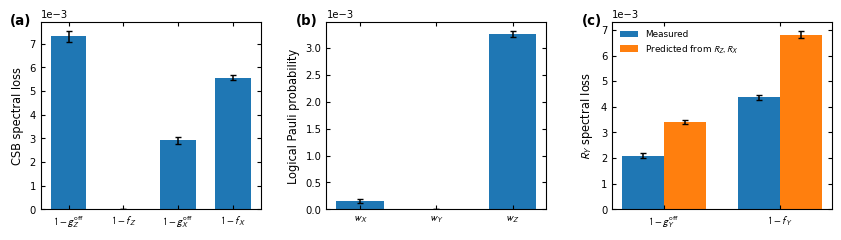

In [5]:
SPECTRA_REPEATS_DF = pd.concat(
    spectra_repeats,
    ignore_index=True,
)

PAULI_REPEATS_DF = pd.concat(
    pauli_repeats,
    ignore_index=True,
)

RY_REPEATS_DF = pd.concat(
    ry_repeats,
    ignore_index=True,
)

RB_REPEATS_DF = pd.concat(
    rb_repeats,
    ignore_index=True,
)


def mean_std_summary(df, group_cols, value_cols):
    agg = {}

    for col in value_cols:
        agg[f"{col}_mean"] = (col, "mean")
        agg[f"{col}_std"] = (col, "std")

    out = df.groupby(
        group_cols,
        as_index=False,
    ).agg(**agg)

    for col in out.columns:
        if col.endswith("_std"):
            out[col] = out[col].fillna(0.0)

    return out


# ============================================================
# Spectral summary
# ============================================================

SPECTRA_SUMMARY = mean_std_summary(
    SPECTRA_REPEATS_DF,
    ["target_gate"],
    [
        "g_offdiag_note",
        "delta_theta",
        "g_axis",
        "process_infidelity",
    ],
)


# ============================================================
# Pauli model summary
# ============================================================

pauli_summary_row = {}

for col in [
    "p_I",
    "p_X",
    "p_Y",
    "p_Z",
    "f_X",
    "f_Y",
    "f_Z",
]:
    values = PAULI_REPEATS_DF[
        col
    ].to_numpy(float)

    pauli_summary_row[
        f"{col}_mean"
    ] = float(np.mean(values))

    pauli_summary_row[
        f"{col}_std"
    ] = (
        float(np.std(values, ddof=1))
        if len(values) > 1
        else 0.0
    )

PAULI_SUMMARY = pd.DataFrame(
    [pauli_summary_row]
)


# ============================================================
# Held-out RY validation summary
# ============================================================

RY_SUMMARY = mean_std_summary(
    RY_REPEATS_DF,
    ["RY_spectrum"],
    [
        "measured",
        "predicted_from_RZ_RX",
        "abs_difference",
    ],
)


# ============================================================
# Random-circuit PEC summary
# ============================================================

RB_SUMMARY = mean_std_summary(
    RB_REPEATS_DF,
    ["rb_depth"],
    [
        "noisy_expectation",
        "pec_expectation",
    ],
)


# ============================================================
# Display
# ============================================================

display(
    SPECTRA_SUMMARY[
        [
            "target_gate",
            "g_offdiag_note_mean","g_offdiag_note_std",
            "delta_theta_mean","delta_theta_std",
            "g_axis_mean",
            "process_infidelity_mean",
        ]
    ]
)

display(
    RB_SUMMARY[
        [
            "rb_depth",
            "noisy_expectation_mean", "noisy_expectation_std",
            "pec_expectation_mean", "pec_expectation_std",
        ]
    ]
)



# ============================================================
# Prepare data
# ============================================================

rz = SPECTRA_SUMMARY[
    SPECTRA_SUMMARY["target_gate"] == "RZ90"
].iloc[0]

rx = SPECTRA_SUMMARY[
    SPECTRA_SUMMARY["target_gate"] == "RX90"
].iloc[0]


# ------------------------------------------------------------
# (a) Spectral losses used for Pauli learning
# ------------------------------------------------------------

spectral_labels = [
    r"$1-g_Z^{\rm off}$",
    r"$1-f_Z$",
    r"$1-g_X^{\rm off}$",
    r"$1-f_X$",
]

spectral_values = np.array([
    1.0 - rz["g_offdiag_note_mean"],
    1.0 - rz["g_axis_mean"],
    1.0 - rx["g_offdiag_note_mean"],
    1.0 - rx["g_axis_mean"],
], dtype=float)

# std is unchanged under y -> 1-y
spectral_errors = np.array([
    rz["g_offdiag_note_std"],
    rz["g_axis_std"],
    rx["g_offdiag_note_std"],
    rx["g_axis_std"],
], dtype=float)


# ------------------------------------------------------------
# (b) Learned Pauli probabilities
# ------------------------------------------------------------

p_row = PAULI_SUMMARY.iloc[0]

pauli_labels = [
    r"$w_X$",
    r"$w_Y$",
    r"$w_Z$",
]

pauli_values = np.array([
    p_row["p_X_mean"],
    p_row["p_Y_mean"],
    p_row["p_Z_mean"],
], dtype=float)

pauli_errors = np.array([
    p_row["p_X_std"],
    p_row["p_Y_std"],
    p_row["p_Z_std"],
], dtype=float)


# ------------------------------------------------------------
# (c) Held-out RY spectral-loss validation
# ------------------------------------------------------------

ry_off = RY_SUMMARY[
    RY_SUMMARY["RY_spectrum"] == "g_offdiag = w_I - w_Y"
].iloc[0]

ry_axis = RY_SUMMARY[
    RY_SUMMARY["RY_spectrum"] == "g_axis = f_Y"
].iloc[0]

ry_labels = [
    r"$1-g_Y^{\rm off}$",
    r"$1-f_Y$",
]

# Convert spectral factors to losses
ry_measured = np.array([
    1.0 - ry_off["measured_mean"],
    1.0 - ry_axis["measured_mean"],
], dtype=float)

ry_measured_error = np.array([
    ry_off["measured_std"],
    ry_axis["measured_std"],
], dtype=float)

ry_predicted = np.array([
    1.0 - ry_off["predicted_from_RZ_RX_mean"],
    1.0 - ry_axis["predicted_from_RZ_RX_mean"],
], dtype=float)

ry_predicted_error = np.array([
    ry_off["predicted_from_RZ_RX_std"],
    ry_axis["predicted_from_RZ_RX_std"],
], dtype=float)


# ============================================================
# Plot
# ============================================================

with mpl.rc_context(PAPER_RC):

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(DOUBLE_COLUMN_WIDTH, 2.55),
    )


    # ========================================================
    # (a) CSB spectral losses
    # ========================================================

    ax = axes[0]

    x_pos = np.arange(len(spectral_labels))

    ax.bar(
        x_pos,
        spectral_values,
        yerr=(
            spectral_errors
            if N_COMPLETE_REPEATS > 1
            else None
        ),
        capsize=2.0,
        width=0.65,
    )

    ax.set_xticks(
        x_pos,
        spectral_labels,
    )

    ax.set_ylabel(
        "CSB spectral loss"
    )

    # losses are small, scientific notation is clearer
    ax.ticklabel_format(
        axis="y",
        style="sci",
        scilimits=(0, 0),
    )

    format_axis(ax)
    panel_label(ax, "(a)")


    # ========================================================
    # (b) Learned logical Pauli probabilities
    # ========================================================

    ax = axes[1]

    x_pos = np.arange(len(pauli_labels))

    ax.bar(
        x_pos,
        pauli_values,
        yerr=(
            pauli_errors
            if N_COMPLETE_REPEATS > 1
            else None
        ),
        capsize=2.0,
        width=0.62,
    )

    ax.set_xticks(
        x_pos,
        pauli_labels,
    )

    ax.set_ylabel(
        "Logical Pauli probability"
    )

    ax.ticklabel_format(
        axis="y",
        style="sci",
        scilimits=(0, 0),
    )

    format_axis(ax)
    panel_label(ax, "(b)")


    # ========================================================
    # (c) Held-out RY spectral-loss validation
    # ========================================================

    ax = axes[2]

    x_pos = np.arange(len(ry_labels))
    width = 0.36

    ax.bar(
        x_pos - width / 2,
        ry_measured,
        width=width,
        yerr=(
            ry_measured_error
            if N_COMPLETE_REPEATS > 1
            else None
        ),
        capsize=2.0,
        label="Measured",
    )

    ax.bar(
        x_pos + width / 2,
        ry_predicted,
        width=width,
        yerr=(
            ry_predicted_error
            if N_COMPLETE_REPEATS > 1
            else None
        ),
        capsize=2.0,
        label=r"Predicted from $R_Z,R_X$",
    )

    ax.set_xticks(
        x_pos,
        ry_labels,
    )

    ax.set_ylabel(
        r"$R_Y$ spectral loss"
    )

    ax.ticklabel_format(
        axis="y",
        style="sci",
        scilimits=(0, 0),
    )

    ax.legend(
        frameon=False,
    )

    format_axis(ax)
    panel_label(ax, "(c)")


    # ========================================================
    # Layout
    # ========================================================

    fig.subplots_adjust(
        left=0.075,
        right=0.995,
        bottom=0.22,
        top=0.955,
        wspace=0.30,
    )

    # save_pdf(
    #     fig,
    #     "coherent_phase_gate_pauli_learning.pdf",
    # )

    plt.show()

## 5. Random-circuit PEC validation

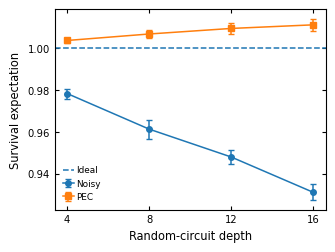

In [6]:
plot_rb = RB_SUMMARY.sort_values(
    "rb_depth"
).reset_index(drop=True)

depth = plot_rb["rb_depth"].to_numpy(int)
noisy_mean = plot_rb["noisy_expectation_mean"].to_numpy(float)
noisy_std = plot_rb["noisy_expectation_std"].to_numpy(float)
pec_mean = plot_rb["pec_expectation_mean"].to_numpy(float)
pec_std = plot_rb["pec_expectation_std"].to_numpy(float)

with mpl.rc_context(PAPER_RC):
    fig, ax = plt.subplots(
        figsize=(SINGLE_COLUMN_WIDTH, 2.55),
    )

    ax.axhline(
        1.0,
        linestyle="--",
        linewidth=1.1,
        label="Ideal",
    )

    ax.errorbar(
        depth,
        noisy_mean,
        yerr=noisy_std if N_COMPLETE_REPEATS > 1 else None,
        marker="o",
        linestyle="-",
        capsize=2.0,
        label="Noisy",
    )

    ax.errorbar(
        depth,
        pec_mean,
        yerr=pec_std if N_COMPLETE_REPEATS > 1 else None,
        marker="s",
        linestyle="-",
        capsize=2.0,
        label="PEC",
    )

    ax.set_xticks(depth)
    ax.set_xlabel("Random-circuit depth")
    ax.set_ylabel("Survival expectation")

    ax.legend(
        loc="best",
        frameon=False,
        handlelength=1.25,
        handletextpad=0.30,
    )

    format_axis(ax)

    fig.subplots_adjust(
        left=0.20,
        right=0.985,
        bottom=0.19,
        top=0.975,
    )

    # save_pdf(
    #     fig,
    #     "coherent_phase_gate_pec_validation.pdf",
    # )
    plt.show()

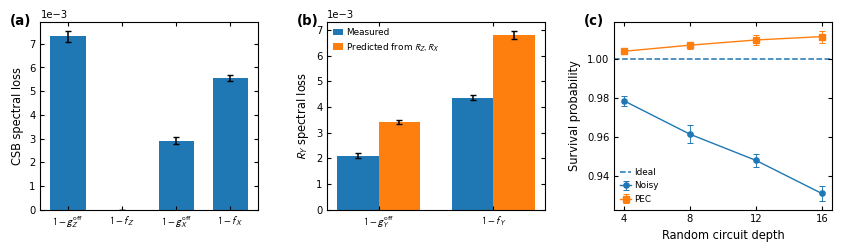

In [7]:
# ============================================================
# Prepare data
# ============================================================

# ------------------------------------------------------------
# (a) RZ / RX spectral losses used for Pauli learning
# ------------------------------------------------------------

rz = SPECTRA_SUMMARY[
    SPECTRA_SUMMARY["target_gate"] == "RZ90"
].iloc[0]

rx = SPECTRA_SUMMARY[
    SPECTRA_SUMMARY["target_gate"] == "RX90"
].iloc[0]

spectral_labels = [
    r"$1-g_Z^{\rm off}$",
    r"$1-f_Z$",
    r"$1-g_X^{\rm off}$",
    r"$1-f_X$",
]

spectral_values = np.array([
    1.0 - rz["g_offdiag_note_mean"],
    1.0 - rz["g_axis_mean"],
    1.0 - rx["g_offdiag_note_mean"],
    1.0 - rx["g_axis_mean"],
], dtype=float)

# std is unchanged under y -> 1-y
spectral_errors = np.array([
    rz["g_offdiag_note_std"],
    rz["g_axis_std"],
    rx["g_offdiag_note_std"],
    rx["g_axis_std"],
], dtype=float)


# ------------------------------------------------------------
# (b) Held-out RY spectral-loss validation
# ------------------------------------------------------------

ry_off = RY_SUMMARY[
    RY_SUMMARY["RY_spectrum"] == "g_offdiag = w_I - w_Y"
].iloc[0]

ry_axis = RY_SUMMARY[
    RY_SUMMARY["RY_spectrum"] == "g_axis = f_Y"
].iloc[0]

ry_labels = [
    r"$1-g_Y^{\rm off}$",
    r"$1-f_Y$",
]

ry_measured = np.array([
    1.0 - ry_off["measured_mean"],
    1.0 - ry_axis["measured_mean"],
], dtype=float)

ry_measured_error = np.array([
    ry_off["measured_std"],
    ry_axis["measured_std"],
], dtype=float)

ry_predicted = np.array([
    1.0 - ry_off["predicted_from_RZ_RX_mean"],
    1.0 - ry_axis["predicted_from_RZ_RX_mean"],
], dtype=float)

ry_predicted_error = np.array([
    ry_off["predicted_from_RZ_RX_std"],
    ry_axis["predicted_from_RZ_RX_std"],
], dtype=float)


# ------------------------------------------------------------
# (c) Operational PEC validation
# ------------------------------------------------------------

plot_rb = RB_SUMMARY.sort_values(
    "rb_depth"
).reset_index(drop=True)

depth = plot_rb[
    "rb_depth"
].to_numpy(dtype=int)

noisy_mean = plot_rb[
    "noisy_expectation_mean"
].to_numpy(dtype=float)

noisy_std = plot_rb[
    "noisy_expectation_std"
].to_numpy(dtype=float)

pec_mean = plot_rb[
    "pec_expectation_mean"
].to_numpy(dtype=float)

pec_std = plot_rb[
    "pec_expectation_std"
].to_numpy(dtype=float)


# ============================================================
# Plot
# ============================================================

with mpl.rc_context(PAPER_RC):

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(DOUBLE_COLUMN_WIDTH, 2.55),
    )


    # ========================================================
    # (a) CSB spectral losses used for learning
    # ========================================================

    ax = axes[0]

    x_pos = np.arange(
        len(spectral_labels)
    )

    ax.bar(
        x_pos,
        spectral_values,
        yerr=(
            spectral_errors
            if N_COMPLETE_REPEATS > 1
            else None
        ),
        capsize=2.0,
        width=0.65,
    )

    ax.set_xticks(
        x_pos,
        spectral_labels,
    )

    ax.set_ylabel(
        "CSB spectral loss"
    )

    ax.ticklabel_format(
        axis="y",
        style="sci",
        scilimits=(0, 0),
    )

    format_axis(ax)
    panel_label(ax, "(a)")


    # ========================================================
    # (b) Held-out RY spectral-loss validation
    # ========================================================

    ax = axes[1]

    x_pos = np.arange(
        len(ry_labels)
    )

    width = 0.36

    ax.bar(
        x_pos - width / 2,
        ry_measured,
        width=width,
        yerr=(
            ry_measured_error
            if N_COMPLETE_REPEATS > 1
            else None
        ),
        capsize=2.0,
        label="Measured",
    )

    ax.bar(
        x_pos + width / 2,
        ry_predicted,
        width=width,
        yerr=(
            ry_predicted_error
            if N_COMPLETE_REPEATS > 1
            else None
        ),
        capsize=2.0,
        label=r"Predicted from $R_Z,R_X$",
    )

    ax.set_xticks(
        x_pos,
        ry_labels,
    )

    ax.set_ylabel(
        r"$R_Y$ spectral loss"
    )

    ax.ticklabel_format(
        axis="y",
        style="sci",
        scilimits=(0, 0),
    )

    ax.legend(
        loc="best",
        frameon=False,
        handlelength=1.15,
        handletextpad=0.30,
        borderaxespad=0.25,
    )

    format_axis(ax)
    panel_label(ax, "(b)")


    # ========================================================
    # (c) PEC validation on random logical circuits
    # ========================================================

    ax = axes[2]

    ax.axhline(
        1.0,
        linestyle="--",
        linewidth=1.1,
        label="Ideal",
        zorder=1,
    )

    ax.errorbar(
        depth,
        noisy_mean,
        yerr=(
            noisy_std
            if N_COMPLETE_REPEATS > 1
            else None
        ),
        marker="o",
        linestyle="-",
        linewidth=1.0,
        markersize=3.8,
        capsize=2.0,
        capthick=0.7,
        elinewidth=0.65,
        label="Noisy",
        zorder=3,
    )

    ax.errorbar(
        depth,
        pec_mean,
        yerr=(
            pec_std
            if N_COMPLETE_REPEATS > 1
            else None
        ),
        marker="s",
        linestyle="-",
        linewidth=1.0,
        markersize=3.8,
        capsize=2.0,
        capthick=0.7,
        elinewidth=0.65,
        label="PEC",
        zorder=3,
    )

    ax.set_xticks(depth)

    ax.set_xlabel(
        "Random circuit depth"
    )

    ax.set_ylabel(
        "Survival probability"
    )

    ax.legend(
        loc="best",
        frameon=False,
        handlelength=1.25,
        handletextpad=0.30,
        borderaxespad=0.25,
    )

    format_axis(ax)
    panel_label(ax, "(c)")


    # ========================================================
    # Layout
    # ========================================================

    fig.subplots_adjust(
        left=0.075,
        right=0.995,
        bottom=0.22,
        top=0.955,
        wspace=0.32,
    )


    # ========================================================
    # Save
    # ========================================================

    fig.savefig(
        "coherent_pauli_learning_pec.pdf",
        bbox_inches="tight",
        pad_inches=0.03,
    )
    plt.show()

## 6. Coherent residual diagnostics

In [8]:
COHERENT_DIAGNOSTICS = SPECTRA_SUMMARY[
    [
        "target_gate",
        "delta_theta_mean",
        "delta_theta_std",
        "g_offdiag_note_mean",
        "g_axis_mean",
        "process_infidelity_mean",
    ]
].copy()

COHERENT_DIAGNOSTICS["abs_delta_theta"] = np.abs(
    COHERENT_DIAGNOSTICS["delta_theta_mean"]
)
COHERENT_DIAGNOSTICS["offdiag_loss"] = (
    1.0 - COHERENT_DIAGNOSTICS["g_offdiag_note_mean"]
)
COHERENT_DIAGNOSTICS["axis_loss"] = (
    1.0 - COHERENT_DIAGNOSTICS["g_axis_mean"]
)

display(COHERENT_DIAGNOSTICS)

,target_gate,delta_theta_mean,delta_theta_std,g_offdiag_note_mean,g_axis_mean,process_infidelity_mean,abs_delta_theta,offdiag_loss,axis_loss
0,RX90,-0.000021,0.000289,0.997087,0.994447,0.002845,0.000021,0.002913,0.005553
1,RY90,-0.000170,0.000103,0.997906,0.995634,0.002139,0.000170,0.002094,0.004366
2,RZ90,0.009648,0.000495,0.992687,1.000000,0.003680,0.009648,0.007313,0.000000
